In [70]:
%cd /home/maia-user/NeuroCBIR/
!ls

/home/maia-user/NeuroCBIR
 cbir			     preprocessing
 CBIR.ipynb		     README.md
 CBIR_wholeBrain.ipynb	     reports
 CBIR_wholeBrain_SVF.ipynb   seg_preparation.ipynb
 compute_SVF.ipynb	     subcortical_AE_training.ipynb
 data			    'subcortical_SVF_AE_training copy.ipynb'
 global_AE_training.ipynb   'subcortical_SVF_training .ipynb'
 global_SVF_training.ipynb   training
 model			     utils
 monai_test.ipynb


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [71]:
# import torch
# from model.autoencoder import Conv3DSparseAutoencoder
# from torchsummary import summary

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Input size: [160, 176, 208]
# input_size = [64, 80, 48]

# # Initialize model and move it to the correct device
# autoencoder = Conv3DSparseAutoencoder().to(device)

# # Run summary — torchsummary will match the device of the model
# _=summary(autoencoder, (1, *input_size))

In [72]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42


In [73]:
# # Loading MRI  paths
# from preprocessing.nii2npy import convert_nii_to_npy
# from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# dataset_path = "/home/maia-user/Dataset/OASIS3/"
# file_paths, file_names = list_files_with_extension(dataset_path, extension="align_norm+cropped.nii.gz")

# raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
# raw_image_ids = np.array([file_path.split('/')[1] for file_path in file_paths])  # e.g., "OAS30001"

# # Optional PE
# # pos_en = positionalencoding2d(4, 128, 128).detach().cpu().numpy()
# pos_en = None

# convert_nii_to_npy(raw_image_paths, raw_image_ids, output_dir="/home/maia-user/Dataset/OASIS3_NPY/", pe=pos_en)

(176, 208, 160) 1.0 0.0


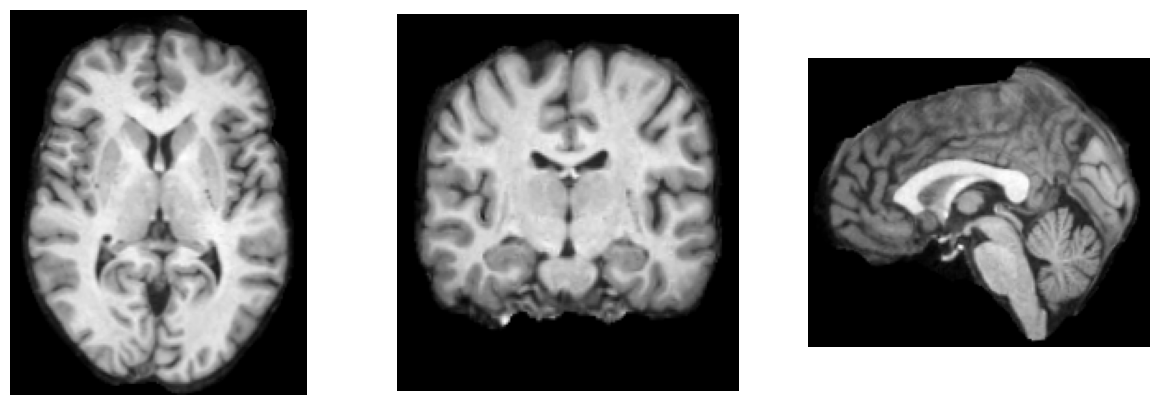

(192, 224, 160) 255 0


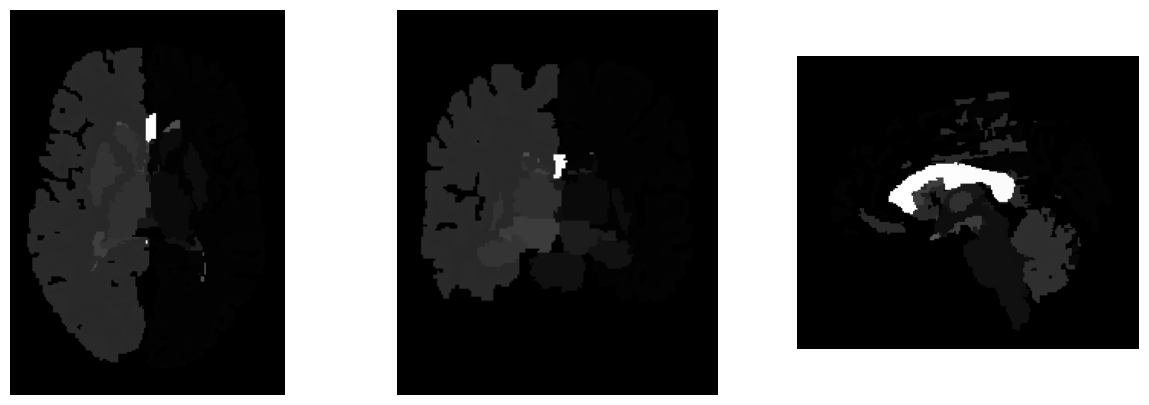

In [74]:
from preprocessing.padding import pad_mri_to_shape

# Load NIfTI file
img_seg = np.load(r"/home/maia-user/Dataset/OASIS3_NPY_UINT/OAS30001_MR_d0129.npy", allow_pickle=True).item()
mri_data = img_seg['image']
mri_data = mri_data.astype(np.float32) / 255.0
seg = img_seg['seg']

# nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
# mri_data = nifti_img.get_fdata()

# Show a single slice (assuming 3D MRI data)
print(mri_data.shape, np.max(mri_data), np.min(mri_data))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mri_data[mri_data.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_data[:, mri_data.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_data[:, :, mri_data.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

# Show a single slice (assuming 3D MRI data)
seg = pad_mri_to_shape(seg, target_shape=(96*2, 112*2, 80*2))
print(seg.shape, np.max(seg), np.min(seg))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(seg[seg.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(seg[:, seg.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(seg[:, :, seg.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()



(96, 112, 80, 3) 5.027 -7.293


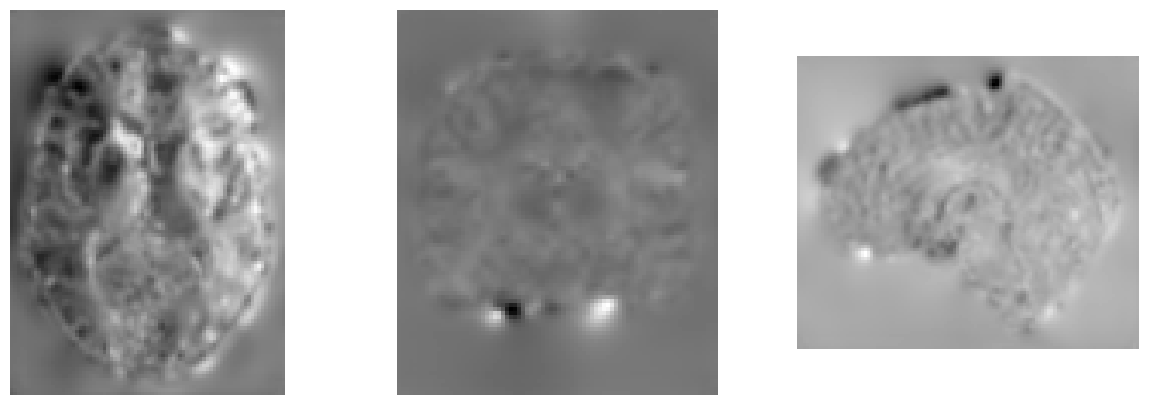

In [75]:
# Load NIfTI file
svf = np.load(r"/home/maia-user/Dataset/OASIS3_NPY_SVF/FROM__OAS30001_MR_d0129__TO__OAS30001_MR_d0757.npy")

# nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
# mri_data = nifti_img.get_fdata()

# Show a single slice (assuming 3D MRI data)
print(svf.shape, np.max(svf), np.min(svf))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(svf[svf.shape[0] // 2, : ,:, 0], cmap="gray")
axes[0].axis("off")
axes[1].imshow(svf[:, svf.shape[1] // 2, :, 1], cmap="gray")
axes[1].axis("off")
axes[2].imshow(svf[:, :, svf.shape[2] // 2, 2], cmap="gray")
axes[2].axis("off")
plt.show()

In [76]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY_SVF/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

In [77]:
# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')


In [78]:

# Some recordings might be removed, i.e. nan labels
# Match svf and labels
raw_labels = np.array([labels_df[labels_df['OASIS_session_label'].apply(lambda x: pd.notna(x) and x in image_id)]['disease_label'].max()
                                for image_id in raw_image_ids]).astype('float32')

# Match svf and age dif
raw_ages_dif = np.array([labels_df[labels_df['OASIS_session_label'].apply(lambda x: pd.notna(x) and x in image_id)]['age_at_visit']
                                for image_id in raw_image_ids]).astype('float32')
raw_ages_dif = raw_ages_dif[:, 1] - raw_ages_dif[:, 0]

# Match svf and id
raw_ids = np.array([labels_df[labels_df['OASISID'].apply(lambda x: pd.notna(x) and x in image_id)]['OASISID'].unique()
                                for image_id in raw_image_ids]).flatten()

KeyboardInterrupt: 

In [ ]:
# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages_dif = raw_ages_dif[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)
print(labels.shape, image_paths.shape, ages_dif.shape, ids.shape)

(2778,) (2778,)
(2778,) (2778,) (2778,) (2778,)


In [ ]:
from preprocessing.split_dataset import stratified_patient_split

# Longitudinal splitting dataset into training and testing sets
train_set, val_set, test_set = stratified_patient_split(image_paths=image_paths, labels=labels, ages_dif=ages_dif, ids=ids)

# Print dataset sizes
print(f"Training samples: {len(train_set['image_paths'])} - IR: {np.sum(train_set['labels'])/len(train_set['image_paths']):.2f}")
print(f"Validation samples: {len(val_set['image_paths'])} - IR: {np.sum(val_set['labels'])/len(val_set['image_paths']):.2f}")
print(f"Testing samples: {len(test_set['image_paths'])} - IR: {np.sum(test_set['labels'])/len(val_set['image_paths']):.2f}")

Training samples: 1931 - IR: 0.16
Validation samples: 345 - IR: 0.17
Testing samples: 502 - IR: 0.15


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from preprocessing.load_dataset import StratifiedBatchSampler, BrainSVFDataset
import torchio as tio

batch_size = 4  # Make sure this is even!

augmentation_transforms = tio.Compose([
                                        # tio.RandomAffine(
                                        #     scales=(0.9, 1.05),        # Random scaling
                                        #     degrees=5,               # Random rotation in degrees
                                        #     translation=5            # Random translation in mm
                                        # ),
                                        tio.RandomNoise(mean=0.0, std=0.02),
                                        # tio.RandomFlip(axes=('LR',)),  # Random left-right flip
                                    ])



# Preparing the dataset to feed the network
train_dataset = BrainSVFDataset(train_set['image_paths'], train_set['ages_dif'], train_set['labels'])
train_sampler = StratifiedBatchSampler(train_dataset, batch_size)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, pin_memory=True, num_workers=1)

val_dataset = BrainSVFDataset(val_set['image_paths'], val_set['ages_dif'], val_set['labels'])
val_sampler = StratifiedBatchSampler(val_dataset, batch_size)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=1)

test_dataset = BrainSVFDataset(test_set['image_paths'], test_set['ages_dif'], test_set['labels'])
test_sampler = StratifiedBatchSampler(test_dataset, batch_size)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=1)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.9609375..2.3828125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.9609375..2.3828125].


torch.Size([3, 112, 80, 96])


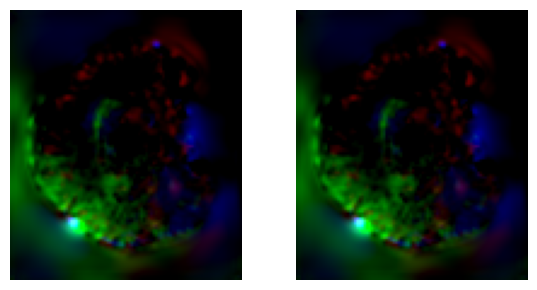

In [ ]:
# Fetch one sample from the dataset
sample_1, sample_2 = train_dataset[0], train_dataset[-55]  # Get the first case

# Extract MRI image and mask
svf_1 = sample_1["svf"].squeeze().detach().cpu().numpy() # Remove channel dimension
svf_2 = sample_1["svf"].squeeze().detach().cpu().numpy() # Remove channel dimension
print(sample_1['svf'].shape)

# if len(svf_1.shape) > 3:
#     subc_st_ind = -3
#     svf_1 = svf_1[subc_st_ind]
#     svf_2 = svf_2[subc_st_ind]

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Load the image
axes[0].imshow(np.transpose(svf_1[:, :,  svf_1.shape[-1] // 2], (1,2,0)))
axes[0].axis('off')

axes[1].imshow(np.transpose(svf_2[:, :,  svf_2.shape[-1] // 2], (1,2,0)))
axes[1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
# Display the plotS
plt.show()

In [ ]:
svf_1[:, :,  svf_1.shape[-1] // 2].shape

(3, 112, 96)

In [ ]:
import torch
from model.svf_autoencoder import Conv3DAutoencoder
from torchsummary import summary

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model and move it to the correct device
input_shape = list(sample_1['svf'].shape)
bottleneck_dim=None
autoencoder = Conv3DAutoencoder(input_shape=input_shape, bottleneck_dim=None).to(device)
pretrained_param = torch.load('./data/pretrained_models/CP_20250516_142452.pth')
# autoencoder.load_state_dict(pretrained_param)

# Keep only matching keys (ignore fully connected layers)
pretrained_dict = pretrained_param
new_model_dict = autoencoder.state_dict()
# Only load parameters that match exactly in name and shape
pretrained_dict = {
    k: v for k, v in pretrained_param.items()
    if k in new_model_dict and v.shape == new_model_dict[k].shape
}
new_model_dict.update(pretrained_dict)
autoencoder.load_state_dict(new_model_dict)

# Run summary — torchsummary will match the device of the model
_=summary(autoencoder, input_shape)


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 7, 5, 6]         --
|    └─Sequential: 2-1                   [-1, 32, 56, 40, 48]      --
|    |    └─Conv3d: 3-1                  [-1, 32, 56, 40, 48]      6,176
|    |    └─GroupNorm: 3-2               [-1, 32, 56, 40, 48]      64
|    |    └─LeakyReLU: 3-3               [-1, 32, 56, 40, 48]      --
|    |    └─Dropout3d: 3-4               [-1, 32, 56, 40, 48]      --
|    └─Sequential: 2-2                   [-1, 32, 28, 20, 24]      --
|    |    └─Conv3d: 3-5                  [-1, 32, 28, 20, 24]      65,568
|    |    └─GroupNorm: 3-6               [-1, 32, 28, 20, 24]      64
|    |    └─LeakyReLU: 3-7               [-1, 32, 28, 20, 24]      --
|    |    └─Dropout3d: 3-8               [-1, 32, 28, 20, 24]      --
|    └─Sequential: 2-3                   [-1, 32, 14, 10, 12]      --
|    |    └─Conv3d: 3-9                  [-1, 32, 14, 10, 12]      65,568
|   

In [ ]:
# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lr = 1e-4
epochs = 50000

decay, no_decay = [], []
for name, param in autoencoder.named_parameters():
    if param.requires_grad:
        if name.endswith("bias") or "bn" in name.lower():
            no_decay.append(param)
        else:
            decay.append(param)

weight_decay = 1e-5
optimizer = torch.optim.AdamW([
    {'params': decay, 'weight_decay': weight_decay},
    {'params': no_decay, 'weight_decay': 0.0}
], lr=lr)

# --- Scheduler ---
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=5e-5, verbose=True
)

criterion = nn.MSELoss()

In [ ]:
from training.report_writer import TrainingReport
from training.train_SVF import train

# Initialize report
report = TrainingReport(autoencoder,
                        input_shape=input_shape, 
                        dataset_info={"N_train": len(train_dataset), 
                                      "IR_train": np.sum(train_set['labels'])/len(train_set['image_paths']),
                                      "N_val": len(val_dataset), 
                                      "IR_val": np.sum(val_set['labels'])/len(val_set['image_paths']),
                                      "N_test": len(test_dataset), 
                                      "IR_test": np.sum(test_set['labels'])/len(test_set['image_paths']),
                                      "batch_size": batch_size}, 
                        optimizer=optimizer, 
                        lr=lr, 
                        weight_decay=weight_decay, 
                        scheduler=scheduler,
                        report_dir="reports/logs"
)


In [ ]:

train_losses, val_losses = train(autoencoder, train_loader, val_loader, optimizer, criterion, device, max_epochs=5000, patience=12, es_warmup=20, scheduler=scheduler, report=report)

Epoch 1 - Training: 100%|██████████| 807/807 [00:43<00:00, 18.52it/s]


[Epoch 1] Train Loss: 0.013940 — Val Loss: 0.016359 — lr = 1.00e-04


Epoch 2 - Training: 100%|██████████| 807/807 [00:42<00:00, 19.00it/s]


[Epoch 2] Train Loss: 0.013923 — Val Loss: 0.016281 — lr = 1.00e-04


Epoch 3 - Training: 100%|██████████| 807/807 [00:43<00:00, 18.62it/s]


...

[Epoch 42] Train Loss: 0.013733 — Val Loss: 0.016158 — lr = 5.00e-05


Epoch 43 - Training: 100%|██████████| 807/807 [00:43<00:00, 18.46it/s]


[Epoch 43] Train Loss: 0.013731 — Val Loss: 0.016154 — lr = 5.00e-05


Epoch 44 - Training: 100%|██████████| 807/807 [00:42<00:00, 19.02it/s]


[Epoch 44] Train Loss: 0.013723 — Val Loss: 0.016073 — lr = 5.00e-05
⏹️ Early stopping triggered at epoch 44


In [ ]:
dataset = BrainSVFDataset(image_paths, ages_dif, labels)

In [ ]:
autoencoder = Conv3DAutoencoder(bottleneck_dim=bottleneck_dim, output_channels=3).to(device)
pretrained_param = torch.load(f'./data/pretrained_models/CP_{report.timestamp}.pth')
autoencoder.load_state_dict(pretrained_param)

<All keys matched successfully>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.2695312..4.5351562].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.429209..4.135536].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.3671875..0.9633789].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2587082..0.61525977].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.70166016..0.9633789].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.64842457..0.497705].


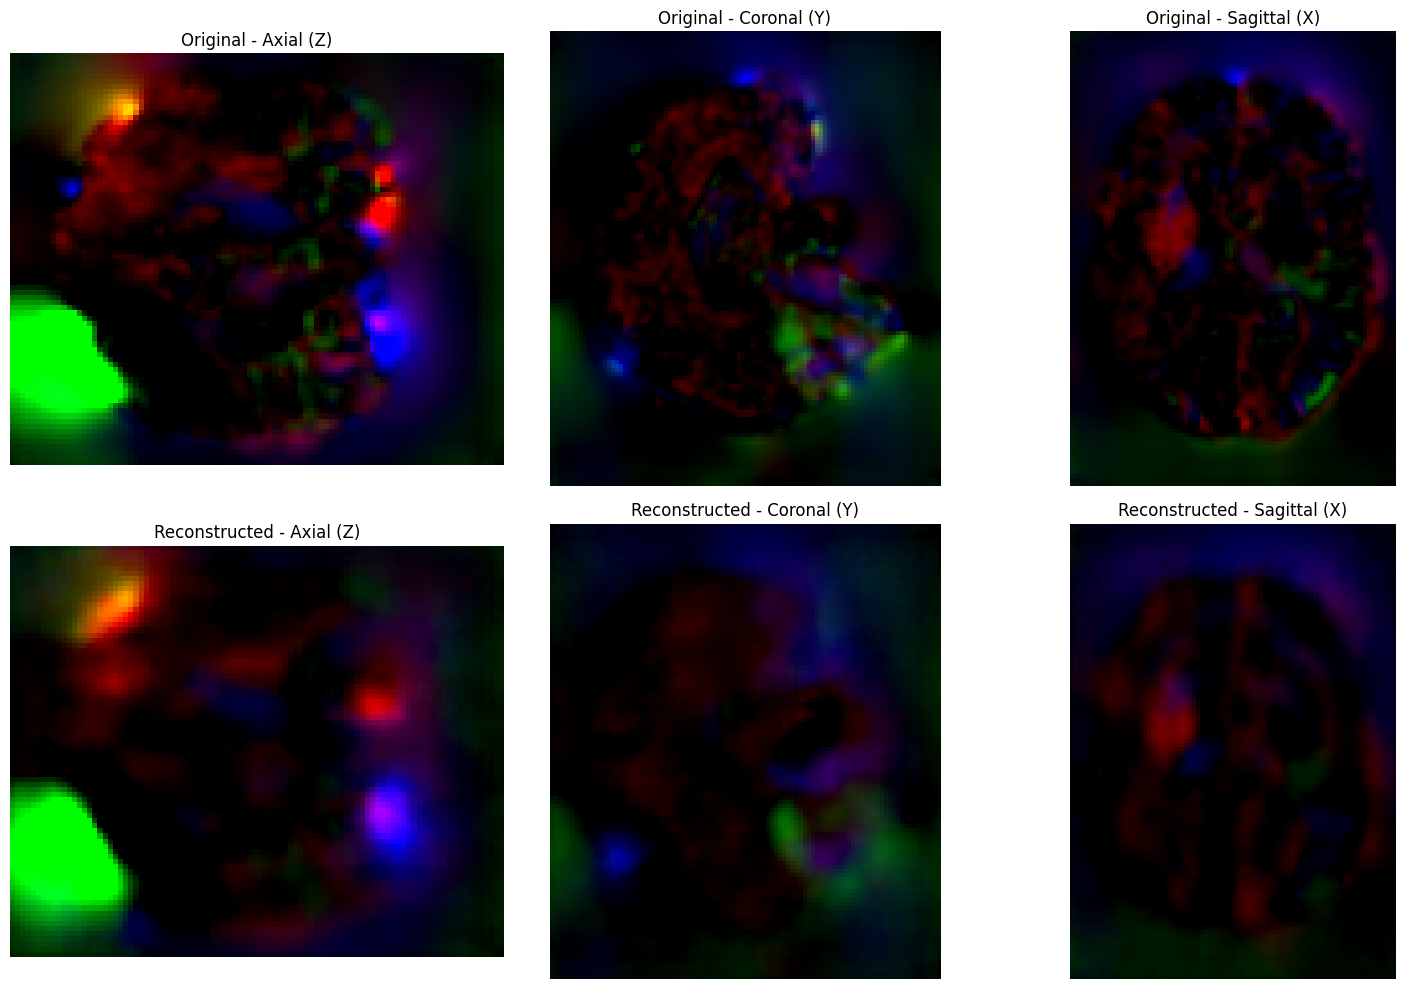

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

sample_1 = dataset[178]  # Any sample

autoencoder.eval()

with torch.no_grad():
    subc_struc_ind = 0
    input_img = sample_1["svf"].to(device, dtype=torch.float32).unsqueeze(dim=0)
    z, reconstructed = autoencoder(input_img)

# Convert to NumPy
original_np = np.transpose(input_img.squeeze().cpu().numpy(), (1,2,3,0))
reconstructed_np = np.transpose(reconstructed.squeeze().cpu().numpy(), (1,2,3,0))

# Compute mid-slices
pz = original_np.shape[0] // 2  # Axial
py = original_np.shape[1] // 2  # Coronal
px = original_np.shape[2] // 2  # Sagittal

# Extract slices
slices = {
    "Axial (Z)":      (original_np[pz, :, :], reconstructed_np[pz, :, :]),
    "Coronal (Y)":    (original_np[:, py, :], reconstructed_np[:, py, :]),
    "Sagittal (X)":   (original_np[:, :, px], reconstructed_np[:, :, px]),
}

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (title, (orig, recon)) in enumerate(slices.items()):
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title(f'Original - {title}')
    axes[0, i].axis('off')

    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].set_title(f'Reconstructed - {title}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def extract_whole_image_features(autoencoder, dataset, device="cuda", subject_ids=None, record_ids=None, dementia_subcortical_indices=None):
    if not dementia_subcortical_indices:
        dementia_subcortical_indices = {
                    "Hippocampus (lh)": 17, "Hippocampus (rh)": 53, "Amygdala (lh)": 18, "Amygdala (rh)": 54, "Thalamus (lh)": 10,
                    "Thalamus (rh)": 49, "Caudate (lh)": 11, "Caudate (rh)": 50, "Putamen (lh)": 12, "Putamen (rh)": 51,
                }

    autoencoder.to(device)
    autoencoder.eval()
    data = []

    for idx in tqdm(range(len(dataset)), desc="Extracting features"):
        # for ss_idx, (key, _) in enumerate(dementia_subcortical_indices.items()):
        key="svf_whole_brain"
        if record_ids is not None:
            record_id = record_ids[idx]

        if subject_ids is not None:
            subject_id = subject_ids[idx]
            
        sample = dataset[idx]
        img = sample["svf"].unsqueeze(0).to(device, dtype=torch.float32)
        
        with torch.no_grad():
            z, _ = autoencoder(img)
        
        data.append({
            "subject_id": subject_id,
            "record_id": record_id,
            "subc_str": key,
            "label": sample["label"].item(),
            "age_dif": sample["age_dif"].item(),
            "features": z.view(-1).cpu().numpy(),
        })
        
    return data

record_ids = [im_path.split("/")[-1].split(".")[0] for im_path in image_paths]

t = -1
dataset = BrainSVFDataset(image_paths[0:t], ages_dif[0:t], labels[0:t])
dataset_feats = extract_whole_image_features(autoencoder, dataset, device="cpu", record_ids=record_ids[0:t], subject_ids=ids[0:t])

np.save(f"./data/dataset_feats_{report.timestamp}.npy", dataset_feats)

Extracting features:   0%|          | 0/2777 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 2777/2777 [02:13<00:00, 20.79it/s]


In [ ]:
pd.DataFrame(dataset_feats).features.values[0].shape

(1680,)